<a href="https://colab.research.google.com/github/KDK-00/deeplearning/blob/main/Korean_Parallel_Corpora_OPUS_Translation_Project_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Korean Parallel Corpora: Machine Translation

Dataset Source: https://huggingface.co/datasets/Moo/korean-parallel-corpora

#### Install Necessary Libraries

In [1]:
%pip install pip -U
%pip install torch transformers datasets evaluate tensorboard
%pip install accelerate -U
%pip install sacrebleu rouge rouge-score nltk
%pip install sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.1.2
    Uninstalling pip-23.1.2:
      Successfully uninstalled pip-23.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.

#### Enter HuggingFace Access Token

In [2]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To login, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: write).
Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in 

#### Import Necessary Libraries

In [3]:
import os, sys
os.environ['TOKENIZERS_PARALLELISM']='false'

from tqdm import tqdm

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk

import transformers
from transformers import DataCollatorForSeq2Seq, AutoModelForSeq2SeqLM, set_seed
from transformers import AutoTokenizer, Seq2SeqTrainingArguments, Seq2SeqTrainer

import datasets
from datasets import Dataset, DatasetDict, load_dataset

import evaluate

!git lfs install

Git LFS initialized.


#### Versions of Software & Libraries Used

In [4]:
library_len = 14
version_len = 12

print(f"+{'-' * (library_len + version_len + 5)}+")
print("|",
      "Library".rjust(library_len),
      "|",
      "Version".ljust(version_len),
      "|")

print(f"|{'*' * (library_len + version_len + 5)}|")

print("|",
      "Python".rjust(library_len),
      "|",
      sys.version[0:6].ljust(version_len),
      "|")

print("|",
      "NumPy".rjust(library_len),
      "|",
      np.__version__.ljust(version_len),
      "|")

print("|",
      "Pandas".rjust(library_len),
      "|",
      pd.__version__.ljust(version_len),
      "|")

print("|",
      "Torch".rjust(library_len),
      "|",
      torch.__version__.ljust(version_len),
      "|")

print("|",
      "Datasets".rjust(library_len),
      "|",
      datasets.__version__.ljust(version_len),
      "|")

print("|",
      "Transformer".rjust(library_len),
      "|",
      transformers.__version__.ljust(version_len),
      "|")

print(f"+{'-' * (library_len + version_len + 5)}+")

+-------------------------------+
|        Library | Version      |
|*******************************|
|         Python | 3.10.1       |
|          NumPy | 1.25.2       |
|         Pandas | 2.0.3        |
|          Torch | 2.3.0+cu121  |
|       Datasets | 2.20.0       |
|    Transformer | 4.41.2       |
+-------------------------------+


#### Ingest & Start Preprocessing Data

In [5]:
data = load_dataset("Moo/korean-parallel-corpora")

data

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/96215 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ko', 'en'],
        num_rows: 96215
    })
    validation: Dataset({
        features: ['ko', 'en'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['ko', 'en'],
        num_rows: 2000
    })
})

#### Convert Dataset to Pandas DataFrame

In [6]:
data.set_format(type="pandas")

df = data['train'][:]

df = df.drop_duplicates()

df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80949 entries, 0 to 80948
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ko      80949 non-null  object
 1   en      80949 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


#### Visual: Length of English Entries

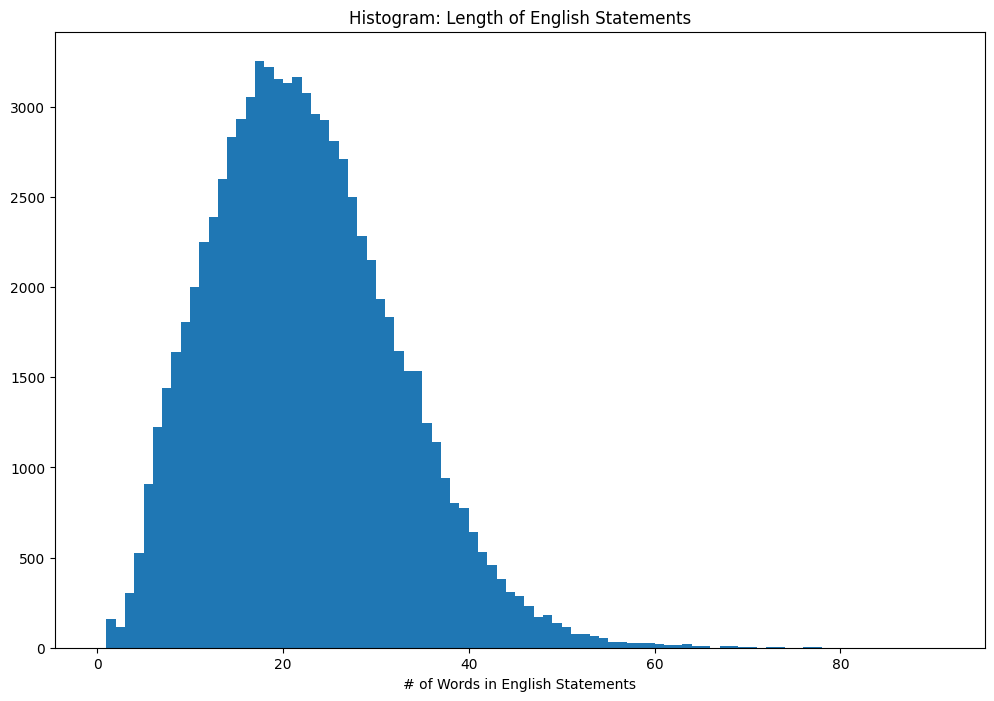

The Maximum length of English text is 90 words.


In [7]:
df['english_length'] = df['en'].str.split().str.len()

max_english_count = max(df['english_length'])

n_bin = max_english_count + 1

df.hist('english_length',
        grid=False,
        figsize=(12,8),
        range=(0,n_bin),
        bins=n_bin)
plt.title('Histogram: Length of English Statements')
plt.xlabel('# of Words in English Statements')
plt.show()

print(f"The Maximum length of English text is {max_english_count} words.")

#### Visual: Length of Korean Entries

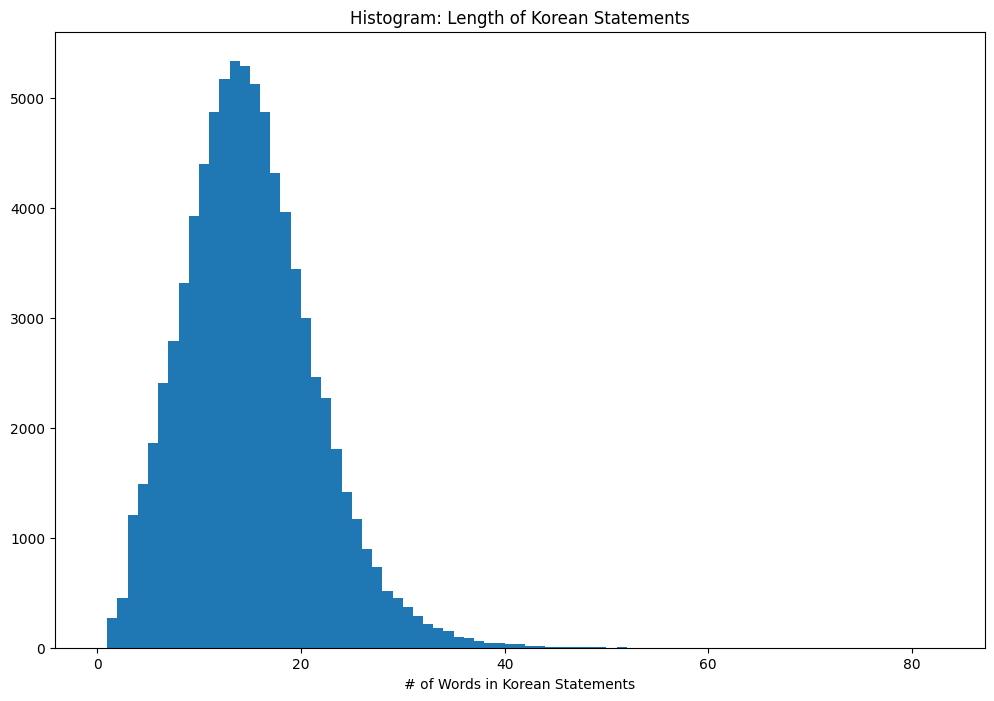

The Maximum length of Korean text is 82 words.


In [8]:
df['korean_length'] = df['ko'].str.split().str.len()

max_korean_count = max(df['korean_length'])

n_bin = max_korean_count + 1

df.hist('korean_length',
        grid=False,
        range=(0,n_bin),
        figsize=(12,8),
        bins=n_bin)
plt.title('Histogram: Length of Korean Statements')
plt.xlabel('# of Words in Korean Statements')
plt.show()

print(f"The Maximum length of Korean text is {max_korean_count} words.")

#### Trim Dataset Size & Drop Unnecessary Features

In [9]:
most_input_words_en = 55
most_input_words_ko = 41
least_input_words = 2

# make sure that English text is less than 55 & more than 2 words
df = df[df['korean_length'] < most_input_words_ko]
df = df[df['korean_length'] > least_input_words]

# make sure that Korean text is less than 41 & more than 2 words
df = df[df['english_length'] < most_input_words_en]
df = df[df['english_length'] > least_input_words]

# reset the index
df = df.reset_index(drop=True)

# Remove columns that are no longer necessary
df = df.drop(columns=['korean_length',
                      'english_length'
                      ]
             )

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79733 entries, 0 to 79732
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ko      79733 non-null  object
 1   en      79733 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


#### Final Preprocessing

In [10]:
all_data = df.to_dict(orient='records')
df = pd.Series(all_data)
df = pd.DataFrame(df)
df.rename(columns={ 0 : 'translation'}, inplace=True)
df.head()

,translation
0,"{'ko': '개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""',..."
1,{'ko': '모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패...
2,"{'ko': '그러나 이것은 또한 책상도 필요로 하지 않는다.', 'en': 'Li..."
3,"{'ko': '79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그..."
4,{'ko': '정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이...


#### Convert to Dataset Format & Split into Train/Test/Eval Datasets

In [11]:
dataset = Dataset.from_pandas(df)

train_testEval = dataset.train_test_split(train_size=0.65)
test_eval = train_testEval['test'].train_test_split(train_size=0.50)

ds = DatasetDict({
    'train' : train_testEval['train'],
    'test' : test_eval['train'],
    'eval' : test_eval['test'],
})

print("Training Dataset Shape:", ds['train'].shape)
print("Testing Dataset Shape:", ds['test'].shape)
print("Evaluation Dataset Shape:", ds['eval'].shape)

print(f"\nTraining Dataset Example:\n{ds['train'][25]}")

Training Dataset Shape: (51826, 1)
Testing Dataset Shape: (13953, 1)
Evaluation Dataset Shape: (13954, 1)

Training Dataset Example:
{'translation': {'en': "The confrontation came Sunday afternoon as Sarkozy and companions were headed for open water in a boat on Lake Winnipesaukee when he spotted Associated Press photographer Jim Cole and freelancer Vince DeWitt aboard Cole's boat, which was outside a buoy barrier monitored by the New Hampshire Marine Patrol.", 'ko': '사르코지 대통령은 이날 위니페소키 호수에서 보트를 타던 중 AP통신의 사진기자인 짐 콜 및 프리랜서인 빈스 드윗과 마주쳤다.'}}


#### Basic Values/Constants

In [12]:
set_seed = 42
NUM_OF_EPOCHS = 6

BATCH_SIZE = 32
LEARNING_RATE = 2e-5

SOURCE_LANGUAGE = "ko"
TARGET_LANGUAGE = "en"

MODEL_CKPT = "Helsinki-NLP/opus-mt-ko-en"

MODEL_NAME = f"{MODEL_CKPT.split(f'/')[-1]}-Korean_Parallel_Corpora"

REPORTS_TO = "tensorboard"
STRATEGY = "epoch"

#### Create Tokenizer

In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


#### Create Preprocessing Function

In [14]:
def tokenizing_function(examples):
    inputs = [ex[SOURCE_LANGUAGE] for ex in examples['translation']]
    targets = [ex[TARGET_LANGUAGE] for ex in examples['translation']]
    model_inputs = tokenizer(inputs,
                             text_target=targets,
                             truncation=True)
    return model_inputs

#### Apply Preprocessing Function to Dataset

In [15]:
encoded_ds = ds.map(tokenizing_function,
                    batched=True)

print(encoded_ds['train'].shape)
print(encoded_ds['test'].shape)
print(encoded_ds['eval'].shape)

Map:   0%|          | 0/51826 [00:00<?, ? examples/s]

Map:   0%|          | 0/13953 [00:00<?, ? examples/s]

Map:   0%|          | 0/13954 [00:00<?, ? examples/s]

(51826, 4)
(13953, 4)
(13954, 4)


#### Instantiate Model

In [16]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CKPT)

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

#### Instantiate Data Collator

In [17]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer,
                                       model=MODEL_CKPT)

#### Create Function to Compute Metrics

In [18]:
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]

    return preds, labels

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds,
                                           skip_special_tokens=True)

    labels = np.where(labels != -100,
                      labels,
                      tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels,
                                            skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds,
                                                     decoded_labels)

    bleu_results = bleu_metric.compute(predictions=decoded_preds,
                                       references=decoded_labels)
    rouge_results = rouge_metric.compute(predictions=decoded_preds,
                                         references=decoded_labels)

    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id)
                       for pred in preds]

    return {"bleu" : bleu_results["score"],
            "rouge" : rouge_results,
            "Prediction Lengths": prediction_lens}

#### Instantiate Training Arguments

In [19]:
args = Seq2SeqTrainingArguments(output_dir=MODEL_NAME,
                                auto_find_batch_size=True,
                                gradient_accumulation_steps=4,
                                eval_accumulation_steps=4,
                                evaluation_strategy="no",
                                save_strategy=STRATEGY,
                                logging_strategy="steps",
                                logging_steps=250,
                                logging_first_step=True,
                                learning_rate=LEARNING_RATE,
                                report_to=REPORTS_TO,
                                weight_decay=0.01,
                                disable_tqdm=False,
                                num_train_epochs=NUM_OF_EPOCHS,
                                predict_with_generate=True,
                                fp16=True,
                                group_by_length=True,
                                hub_private_repo=True,
                                push_to_hub=True
                                )

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


#### Instantiate Trainer

In [20]:
trainer = Seq2SeqTrainer(model=model,
                         args=args,
                         train_dataset=encoded_ds['train'],
                         eval_dataset=encoded_ds['eval'],
                         tokenizer=tokenizer,
                         data_collator=data_collator,
                         compute_metrics=compute_metrics)

#### Train Model

In [21]:
train_results = trainer.train()

Step,Training Loss
1,3.859300
250,3.339000
500,3.216000
750,3.113300
1000,3.096000
1250,3.033900
1500,3.014200
1750,2.917700
2000,2.839000
2250,2.797500


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strate

#### Push Model to HuggingFace Hub (My Profile!)

In [22]:
trainer.push_to_hub()

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}


CommitInfo(commit_url='https://huggingface.co/kdk07718/opus-mt-ko-en-Korean_Parallel_Corpora/commit/311cb4b032d410a36c4b56b87fcb48c6286b642e', commit_message='End of training', commit_description='', oid='311cb4b032d410a36c4b56b87fcb48c6286b642e', pr_url=None, pr_revision=None, pr_num=None)

#### Save & Log Model

In [23]:
trainer.save_model()
trainer.save_state()

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}


#### Evaluate Model

In [24]:
metrics = trainer.evaluate()

Trainer is attempting to log a value of "{'rouge1': 0.43897964380342275, 'rouge2': 0.2025393031649398, 'rougeL': 0.36682270688636515, 'rougeLsum': 0.3669754100641516}" of type <class 'dict'> for key "eval/rouge" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[28, 10, 19, 23, 19, 20, 22, 37, 28, 39, 38, 25, 49, 42, 13, 7, 19, 23, 21, 53, 46, 12, 49, 19, 52, 18, 43, 6, 16, 17, 22, 31, 47, 153, 15, 57, 35, 44, 11, 29, 10, 32, 13, 12, 34, 20, 10, 23, 34, 39, 26, 10, 19, 24, 19, 46, 35, 37, 32, 16, 25, 69, 9, 27, 25, 12, 27, 35, 20, 26, 6, 26, 17, 27, 10, 21, 30, 24, 20, 12, 28, 34, 44, 40, 26, 25, 26, 27, 43, 34, 18, 39, 17, 8, 31, 19, 13, 16, 18, 30, 7, 29, 44, 18, 36, 25, 8, 30, 32, 19, 23, 23, 12, 29, 12, 23, 37, 38, 29, 18, 27, 17, 10, 25, 28, 28, 24, 33, 19, 40, 11, 31, 15, 25, 40, 29, 33, 16, 36, 19, 28, 28, 28, 27, 42, 22, 23, 22, 35, 47, 27, 31, 23, 10, 29, 30, 20, 18, 24, 14, 48,

#### Print Metric Values

In [25]:
print(metrics)

{'eval_loss': 2.6668314933776855, 'eval_bleu': 14.337274277567607, 'eval_rouge': {'rouge1': 0.43897964380342275, 'rouge2': 0.2025393031649398, 'rougeL': 0.36682270688636515, 'rougeLsum': 0.3669754100641516}, 'eval_Prediction Lengths': [28, 10, 19, 23, 19, 20, 22, 37, 28, 39, 38, 25, 49, 42, 13, 7, 19, 23, 21, 53, 46, 12, 49, 19, 52, 18, 43, 6, 16, 17, 22, 31, 47, 153, 15, 57, 35, 44, 11, 29, 10, 32, 13, 12, 34, 20, 10, 23, 34, 39, 26, 10, 19, 24, 19, 46, 35, 37, 32, 16, 25, 69, 9, 27, 25, 12, 27, 35, 20, 26, 6, 26, 17, 27, 10, 21, 30, 24, 20, 12, 28, 34, 44, 40, 26, 25, 26, 27, 43, 34, 18, 39, 17, 8, 31, 19, 13, 16, 18, 30, 7, 29, 44, 18, 36, 25, 8, 30, 32, 19, 23, 23, 12, 29, 12, 23, 37, 38, 29, 18, 27, 17, 10, 25, 28, 28, 24, 33, 19, 40, 11, 31, 15, 25, 40, 29, 33, 16, 36, 19, 28, 28, 28, 27, 42, 22, 23, 22, 35, 47, 27, 31, 23, 10, 29, 30, 20, 18, 24, 14, 48, 22, 51, 36, 39, 34, 44, 31, 16, 18, 26, 21, 15, 16, 11, 11, 26, 10, 32, 11, 38, 10, 31, 37, 32, 37, 29, 39, 28, 24, 13, 19, 24

### Notes & Other Takeaways From This Project
****
- These are not the results I was expecting, but I will learn from this project and incorporate that wisdom in projects going forward.

****

#### Citations

- Model Checkpoint
    > https://huggingface.co/Helsinki-NLP/opus-mt-ko-en

- Metrics
    - Bleu
        > @INPROCEEDINGS{Papineni02bleu:a, author = {Kishore Papineni and Salim Roukos and Todd Ward and Wei-jing Zhu}, title = {BLEU: a Method for Automatic Evaluation of Machine Translation}, booktitle = {}, year = {2002}, pages = {311--318}}
        
        > @inproceedings{lin-och-2004-orange, title = "{ORANGE}: a Method for Evaluating Automatic Evaluation Metrics for Machine Translation", author = "Lin, Chin-Yew and Och, Franz Josef", booktitle = "{COLING} 2004: Proceedings of the 20th International Conference on Computational Linguistics", month = "aug 23{--}aug 27", year = "2004", address = "Geneva, Switzerland", publisher = "COLING", url = "https://www.aclweb.org/anthology/C04-1072", pages = "501--507",}
    
    - Rouge
        > @inproceedings{lin-2004-rouge, title = '{ROUGE}: A Package for Automatic Evaluation of Summaries', author = 'Lin, Chin-Yew', booktitle = 'Text Summarization Branches Out', month = jul, year = '2004', address = 'Barcelona, Spain', publisher = 'Association for Computational Linguistics', url = 'https://www.aclweb.org/anthology/W04-1013', pages = '74--81',}